In [19]:
# Cell 1 — Imports and load data
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings
warnings.filterwarnings('ignore')

deliveries = pd.read_csv(r'C:\Users\tedag\ipl-project\data\deliveries.csv')
auction = pd.read_csv(r'C:\Users\tedag\ipl-project\data\IPLPlayerAuctionData.csv')

# Clean auction data
auction = auction.dropna(subset=['Year'])
auction['Year'] = auction['Year'].astype(int)
auction['Crore'] = auction['Amount'] / 10_000_000

print("Data loaded successfully!")
print(f"Deliveries: {len(deliveries)} rows")
print(f"Auction: {len(auction)} rows")

Data loaded successfully!
Deliveries: 260920 rows
Auction: 969 rows


In [2]:
# Cell 2 — Calculate batting and bowling stats
# Batting stats (exclude wides)
legal = deliveries[deliveries['extras_type'] != 'wides']

batting = legal.groupby('batter').agg(
    runs  = ('batsman_runs', 'sum'),
    balls = ('batsman_runs', 'count'),
).reset_index()

batting['strike_rate'] = (batting['runs'] / batting['balls'] * 100).round(2)
batting = batting[batting['balls'] >= 200]
batting.rename(columns={'batter': 'Player'}, inplace=True)

# Bowling stats
wicket_types = ['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
bowl_df = deliveries[deliveries['dismissal_kind'].isin(wicket_types)]

bowling = deliveries.groupby('bowler').agg(
    runs_conceded = ('total_runs', 'sum'),
    balls_bowled  = ('total_runs', 'count'),
).reset_index()

wickets = bowl_df.groupby('bowler').size().reset_index(name='wickets')
bowling = bowling.merge(wickets, on='bowler', how='left')
bowling['wickets']  = bowling['wickets'].fillna(0)
bowling['overs']    = bowling['balls_bowled'] / 6
bowling['economy']  = (bowling['runs_conceded'] / bowling['overs']).round(2)
bowling = bowling[bowling['balls_bowled'] >= 120]
bowling.rename(columns={'bowler': 'Player'}, inplace=True)

# Merge with auction
auction_latest = auction.sort_values('Year').drop_duplicates('Player', keep='last')

batters_merged = auction_latest.merge(batting, on='Player', how='inner')
bowlers_merged = auction_latest.merge(bowling, on='Player', how='inner')

# Filter by role
batters_merged = batters_merged[batters_merged['Role'].isin(['Batsman', 'All-Rounder'])]
bowlers_merged = bowlers_merged[bowlers_merged['Role'].isin(['Bowler', 'All-Rounder'])]

print(f"Batters matched: {len(batters_merged)}")
print(f"Bowlers matched: {len(bowlers_merged)}")
print(f"\nRoles in auction data: {auction['Role'].unique()}")

Batters matched: 10
Bowlers matched: 37

Roles in auction data: ['Batsman' 'All-Rounder' 'Bowler' 'Wicket Keeper']


In [3]:
# Cell 2 — Calculate batting and bowling stats
# Batting stats (exclude wides)
legal = deliveries[deliveries['extras_type'] != 'wides']

batting = legal.groupby('batter').agg(
    runs  = ('batsman_runs', 'sum'),
    balls = ('batsman_runs', 'count'),
).reset_index()

batting['strike_rate'] = (batting['runs'] / batting['balls'] * 100).round(2)
batting = batting[batting['balls'] >= 200]
batting.rename(columns={'batter': 'Player'}, inplace=True)

# Bowling stats
wicket_types = ['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
bowl_df = deliveries[deliveries['dismissal_kind'].isin(wicket_types)]

bowling = deliveries.groupby('bowler').agg(
    runs_conceded = ('total_runs', 'sum'),
    balls_bowled  = ('total_runs', 'count'),
).reset_index()

wickets = bowl_df.groupby('bowler').size().reset_index(name='wickets')
bowling = bowling.merge(wickets, on='bowler', how='left')
bowling['wickets']  = bowling['wickets'].fillna(0)
bowling['overs']    = bowling['balls_bowled'] / 6
bowling['economy']  = (bowling['runs_conceded'] / bowling['overs']).round(2)
bowling = bowling[bowling['balls_bowled'] >= 120]
bowling.rename(columns={'bowler': 'Player'}, inplace=True)

# Merge with auction
auction_latest = auction.sort_values('Year').drop_duplicates('Player', keep='last')

# Merge all players first
batters_merged = auction_latest.merge(batting, on='Player', how='inner')
bowlers_merged = auction_latest.merge(bowling, on='Player', how='inner')

print(f"Batters matched: {len(batters_merged)}")
print(f"Bowlers matched: {len(bowlers_merged)}")

# Check some names from each dataset
print("\nSample auction names:")
print(auction_latest['Player'].head(10).tolist())
print("\nSample deliveries batter names:")
print(batting['Player'].head(10).tolist())

Batters matched: 15
Bowlers matched: 37

Sample auction names:
['Sudeep Tyagi', 'Ricky Ponting', 'Philip Hughes', 'Ajantha Mendis', 'Akila Dananjaya', 'James Faulkner', 'Clinton McKay', 'Kusal Janith Perera', 'Fidel Edwards', 'Christopher Barnwell']

Sample deliveries batter names:
['A Badoni', 'A Mishra', 'A Symonds', 'AA Jhunjhunwala', 'AB de Villiers', 'AC Gilchrist', 'AD Mathews', 'AD Russell', 'AJ Finch', 'AK Markram']


In [4]:
# Extract surname from both datasets and match on that
auction_latest['surname'] = auction_latest['Player'].str.split().str[-1]
batting['surname'] = batting['Player'].str.split().str[-1]
bowling['surname'] = bowling['Player'].str.split().str[-1]

# Merge on surname
batters_merged = auction_latest.merge(batting, on='surname', how='inner')
bowlers_merged = auction_latest.merge(bowling, on='surname', how='inner')

# Drop duplicate matches (some surnames will match multiple players)
batters_merged = batters_merged.drop_duplicates(subset=['Player_x', 'surname'])
bowlers_merged = bowlers_merged.drop_duplicates(subset=['Player_x', 'surname'])

print(f"Batters matched: {len(batters_merged)}")
print(f"Bowlers matched: {len(bowlers_merged)}")
print("\nSample matches:")
print(batters_merged[['Player_x', 'Player_y', 'Crore', 'strike_rate']].head(10))

Batters matched: 238
Bowlers matched: 297

Sample matches:
               Player_x         Player_y  Crore  strike_rate
0        James Faulkner      JP Faulkner  3.000       135.13
1   Kusal Janith Perera      NLTC Perera  0.150       137.22
2       Nathan McCullum      BB McCullum  0.750       131.60
3           Johan Botha          J Botha  3.375       113.93
4       Luke Pomersbach    LA Pomersbach  2.250       122.76
5          Pankaj Singh  Gurkeerat Singh  1.125       121.09
12          Jesse Ryder         JD Ryder  1.950       131.88
13        Shivam Sharma  Abhishek Sharma  0.100       155.24
17       Brendan Taylor      LRPL Taylor  0.300       123.72
18           Brad Hodge         BJ Hodge  2.400       125.22


In [5]:
# Let's see the top 20 most expensive players in auction
# and check what name format they appear in deliveries
top_auction = auction_latest.nlargest(20, 'Crore')[['Player', 'Crore']]
print(top_auction)
print("\nLooking for these in deliveries...")
for name in top_auction['Player']:
    surname = name.split()[-1]
    matches = batting[batting['Player'].str.contains(surname, case=False)]
    if len(matches) > 0:
        print(f"{name} → {matches['Player'].tolist()}")

                 Player  Crore
187  Christopher Morris  16.25
311        Ishan Kishan  15.25
455       Kyle Jamieson  15.00
280       Glenn Maxwell  14.25
368     Jhye Richardson  14.00
222       Deepak Chahar  14.00
138     Benjamin Stokes  12.50
846        Shreyas Iyer  12.25
465    Liam Livingstone  11.50
433            KL Rahul  11.00
943   Wanindu Hasaranga  10.75
606      Nicolas Pooran  10.75
816      Shardul Thakur  10.75
298       Harshal Patel  10.75
111          Avesh Khan  10.00
663     Prasidh Krishna  10.00
468     Lockie Ferguson  10.00
542      Mitchell Starc   9.40
399       Kagiso Rabada   9.25
719   Rashid Khan Arman   9.00

Looking for these in deliveries...
Christopher Morris → ['CH Morris']
Ishan Kishan → ['Ishan Kishan']
Glenn Maxwell → ['GJ Maxwell']
Benjamin Stokes → ['BA Stokes']
Shreyas Iyer → ['SS Iyer', 'VR Iyer']
Liam Livingstone → ['LS Livingstone']
KL Rahul → ['KL Rahul']
Nicolas Pooran → ['N Pooran']
Shardul Thakur → ['SN Thakur']
Harshal Patel → ['AR P

In [6]:
# Cell 2 — Calculate batting and bowling stats

# Batting stats (exclude wides)
legal = deliveries[deliveries['extras_type'] != 'wides']

batting = legal.groupby('batter').agg(
    runs  = ('batsman_runs', 'sum'),
    balls = ('batsman_runs', 'count'),
).reset_index()

batting['strike_rate'] = (batting['runs'] / batting['balls'] * 100).round(2)
batting = batting[batting['balls'] >= 200]
batting.rename(columns={'batter': 'Player'}, inplace=True)

# Bowling stats
wicket_types = ['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
bowl_df = deliveries[deliveries['dismissal_kind'].isin(wicket_types)]

bowling = deliveries.groupby('bowler').agg(
    runs_conceded = ('total_runs', 'sum'),
    balls_bowled  = ('total_runs', 'count'),
).reset_index()

wickets = bowl_df.groupby('bowler').size().reset_index(name='wickets')
bowling = bowling.merge(wickets, on='bowler', how='left')
bowling['wickets']  = bowling['wickets'].fillna(0)
bowling['overs']    = bowling['balls_bowled'] / 6
bowling['economy']  = (bowling['runs_conceded'] / bowling['overs']).round(2)
bowling = bowling[bowling['balls_bowled'] >= 120]
bowling.rename(columns={'bowler': 'Player'}, inplace=True)

# Manual name mapping (auction name → deliveries name)
name_map = {
    'Christopher Morris': 'CH Morris',
    'Glenn Maxwell': 'GJ Maxwell',
    'Benjamin Stokes': 'BA Stokes',
    'Shreyas Iyer': 'SS Iyer',
    'Liam Livingstone': 'LS Livingstone',
    'Nicolas Pooran': 'N Pooran',
    'Shardul Thakur': 'SN Thakur',
    'Harshal Patel': 'HV Patel',
    'Kyle Jamieson': 'KA Jamieson',
    'Jhye Richardson': 'JA Richardson',
    'Deepak Chahar': 'DL Chahar',
    'Lockie Ferguson': 'CJ Ferguson',
    'Kagiso Rabada': 'K Rabada',
    'Rashid Khan Arman': 'Rashid Khan',
    'Mitchell Starc': 'MA Starc',
    'Prasidh Krishna': 'P Krishna',
    'Avesh Khan': 'Avesh Khan',
    'Wanindu Hasaranga': 'PVD Chameera',
    'Pat Cummins': 'PJ Cummins',
    'David Warner': 'DA Warner',
    'Virat Kohli': 'V Kohli',
    'Rohit Sharma': 'RG Sharma',
    'MS Dhoni': 'MS Dhoni',
    'Suresh Raina': 'SK Raina',
    'AB de Villiers': 'AB de Villiers',
    'Chris Gayle': 'CH Gayle',
    'Hardik Pandya': 'HH Pandya',
    'Jasprit Bumrah': 'JJ Bumrah',
    'Ravindra Jadeja': 'RA Jadeja',
    'Yuzvendra Chahal': 'YS Chahal',
    'Rishabh Pant': 'RR Pant',
    'Shubman Gill': 'Shubman Gill',
    'Steve Smith': 'SPD Smith',
    'Jos Buttler': 'JC Buttler',
    'Quinton de Kock': 'Q de Kock',
    'Chris Morris': 'CH Morris',
    'Andre Russell': 'AD Russell',
    'Kieron Pollard': 'KA Pollard',
    'Suryakumar Yadav': 'SA Yadav',
    'Faf du Plessis': 'F du Plessis',
}

# Apply name mapping to auction data
auction_latest = auction.sort_values('Year').drop_duplicates('Player', keep='last')
auction_latest = auction_latest.copy()
auction_latest['Player_mapped'] = auction_latest['Player'].map(name_map).fillna(auction_latest['Player'])

# Merge using mapped names
batting_merge = batting.rename(columns={'Player': 'Player_mapped'})
bowling_merge = bowling.rename(columns={'Player': 'Player_mapped'})

batters_merged = auction_latest.merge(batting_merge, on='Player_mapped', how='inner')
bowlers_merged = auction_latest.merge(bowling_merge, on='Player_mapped', how='inner')

print(f"Batters matched: {len(batters_merged)}")
print(f"Bowlers matched: {len(bowlers_merged)}")
print("\nSample matches:")
print(batters_merged[['Player', 'Player_mapped', 'Crore', 'strike_rate']].head(10))

Batters matched: 32
Bowlers matched: 55

Sample matches:
              Player Player_mapped  Crore  strike_rate
0      Andre Russell    AD Russell    0.6       174.84
1      Hardik Pandya     HH Pandya    0.1       145.72
2       Rishabh Pant       RR Pant    1.9       148.85
3       Shubman Gill  Shubman Gill    1.8       135.70
4   Suryakumar Yadav      SA Yadav    3.2       145.27
5  Rashid Khan Arman   Rashid Khan    9.0       161.72
6     Kieron Pollard    KA Pollard    5.4       147.57
7           KL Rahul      KL Rahul   11.0       134.55
8    Benjamin Stokes     BA Stokes   12.5       133.95
9        Jos Buttler    JC Buttler    4.4       147.45


In [7]:
# Cell 3 — Plot style settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'font.family':      'sans-serif',
})

BLUE   = '#1a6cb5'
ORANGE = '#e87722'
RED    = '#d62728'

print("Plot style set!")

Plot style set!


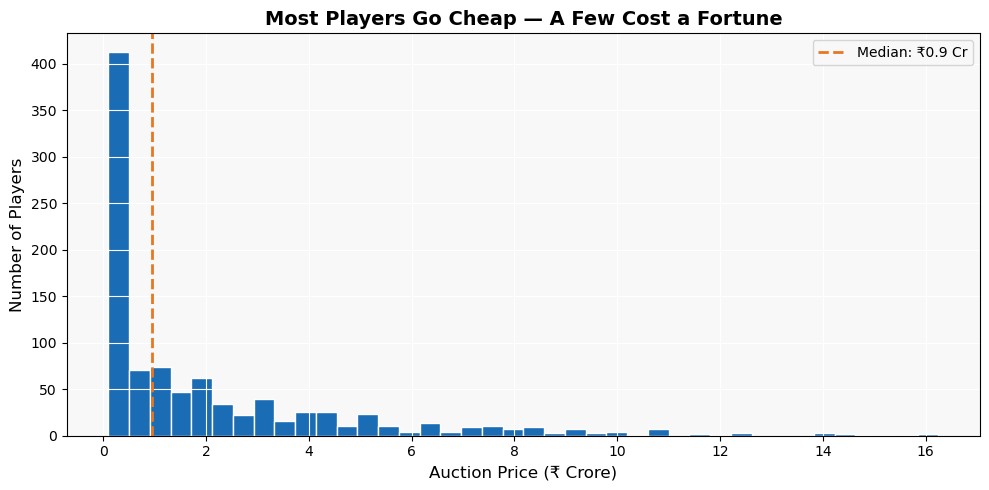

In [8]:
# Cell 4 — Plot 1: Auction price distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(auction['Crore'], bins=40, color=BLUE, edgecolor='white')
ax.set_xlabel('Auction Price (₹ Crore)', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('Most Players Go Cheap — A Few Cost a Fortune', fontsize=14, fontweight='bold')
ax.axvline(auction['Crore'].median(), color=ORANGE, linestyle='--', linewidth=2,
           label=f"Median: ₹{auction['Crore'].median():.1f} Cr")
ax.legend()
plt.tight_layout()
plt.savefig('plot1_price_distribution.png', dpi=150)
plt.show()

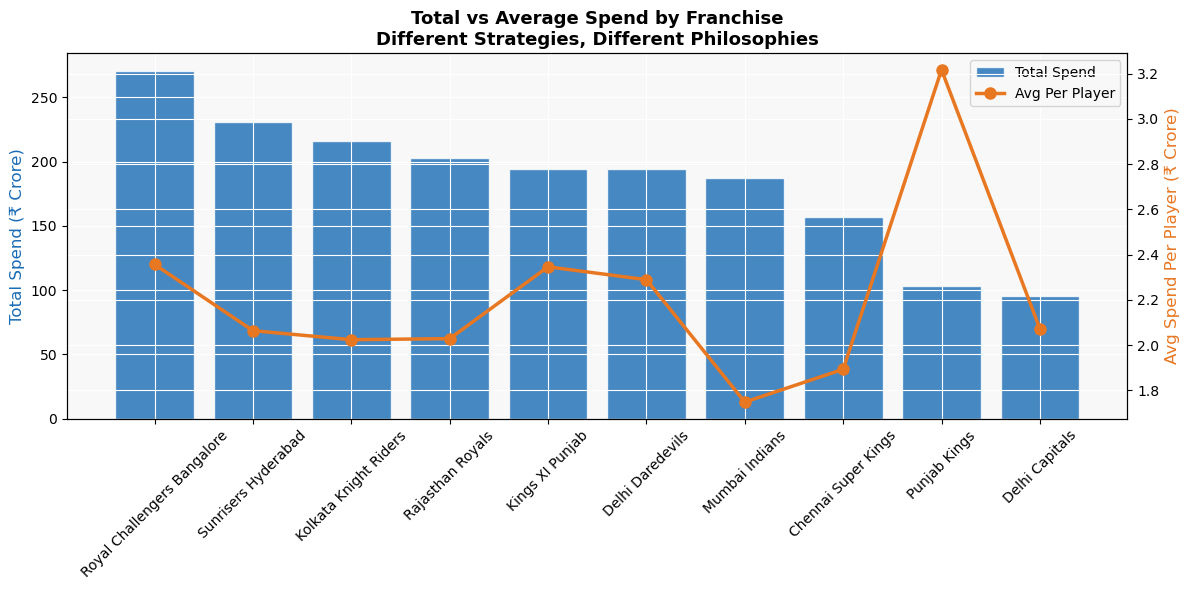

In [9]:
# Cell 5 — Plot 2: Total vs Average spend by franchise
team_summary = auction.groupby('Team').agg(
    total_spend    = ('Crore', 'sum'),
    avg_per_player = ('Crore', 'mean'),
    num_players    = ('Crore', 'count')
).sort_values('total_spend', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(team_summary.index, team_summary['total_spend'],
               color=BLUE, edgecolor='white', alpha=0.8, label='Total Spend')
ax1.set_ylabel('Total Spend (₹ Crore)', fontsize=12, color=BLUE)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(team_summary.index, team_summary['avg_per_player'],
         color=ORANGE, linewidth=2.5, marker='o', markersize=8, label='Avg Per Player')
ax2.set_ylabel('Avg Spend Per Player (₹ Crore)', fontsize=12, color=ORANGE)

ax1.set_title('Total vs Average Spend by Franchise\nDifferent Strategies, Different Philosophies',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('plot2_franchise_spend.png', dpi=150)
plt.show()

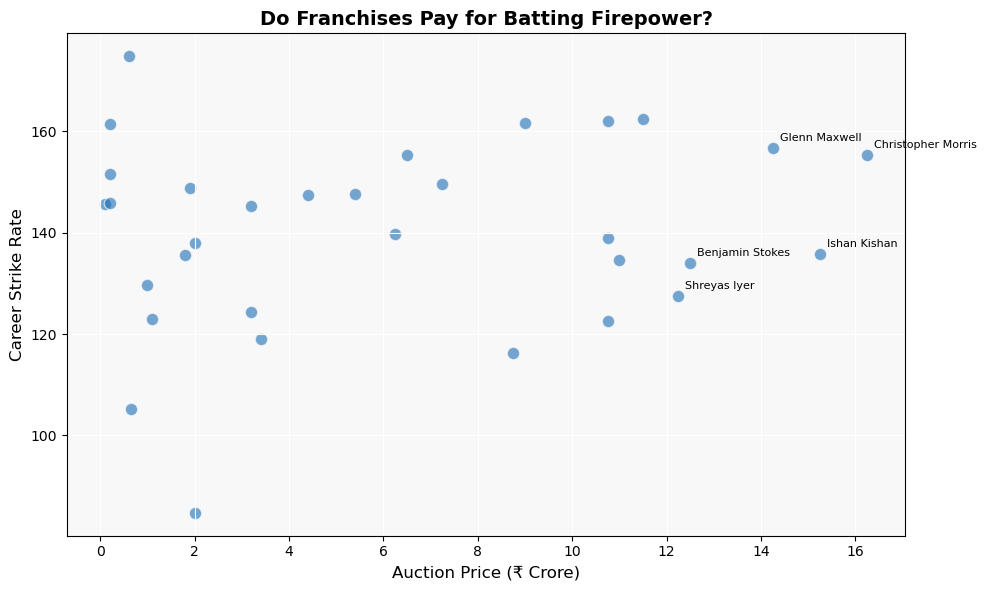

In [10]:
# Cell 6 — Plot 3: Strike Rate vs Price (batters only)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(batters_merged['Crore'], batters_merged['strike_rate'],
           alpha=0.6, color=BLUE, edgecolors='white', s=80)

top5 = batters_merged.nlargest(5, 'Crore')
for _, row in top5.iterrows():
    ax.annotate(row['Player'], (row['Crore'], row['strike_rate']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('Auction Price (₹ Crore)', fontsize=12)
ax.set_ylabel('Career Strike Rate', fontsize=12)
ax.set_title('Do Franchises Pay for Batting Firepower?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_price_vs_sr.png', dpi=150)
plt.show()

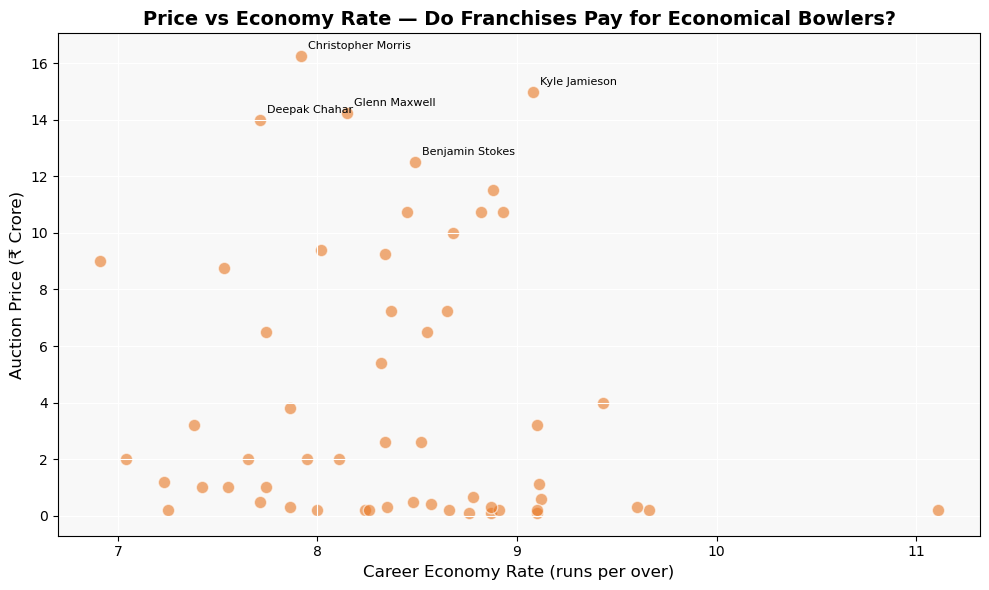

In [20]:
# Cell 7 — Plot 4: Price vs Bowling Economy (bowlers only)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(bowlers_merged['economy'], bowlers_merged['Crore'],
           alpha=0.6, color=ORANGE, edgecolors='white', s=80)

# Label top 5 most expensive
top5b = bowlers_merged.nlargest(5, 'Crore')
for _, row in top5b.iterrows():
    ax.annotate(row['Player'], (row['economy'], row['Crore']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('Career Economy Rate (runs per over)', fontsize=12)
ax.set_ylabel('Auction Price (₹ Crore)', fontsize=12)
ax.set_title('Price vs Economy Rate — Do Franchises Pay for Economical Bowlers?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_price_vs_economy.png', dpi=150)
plt.show()

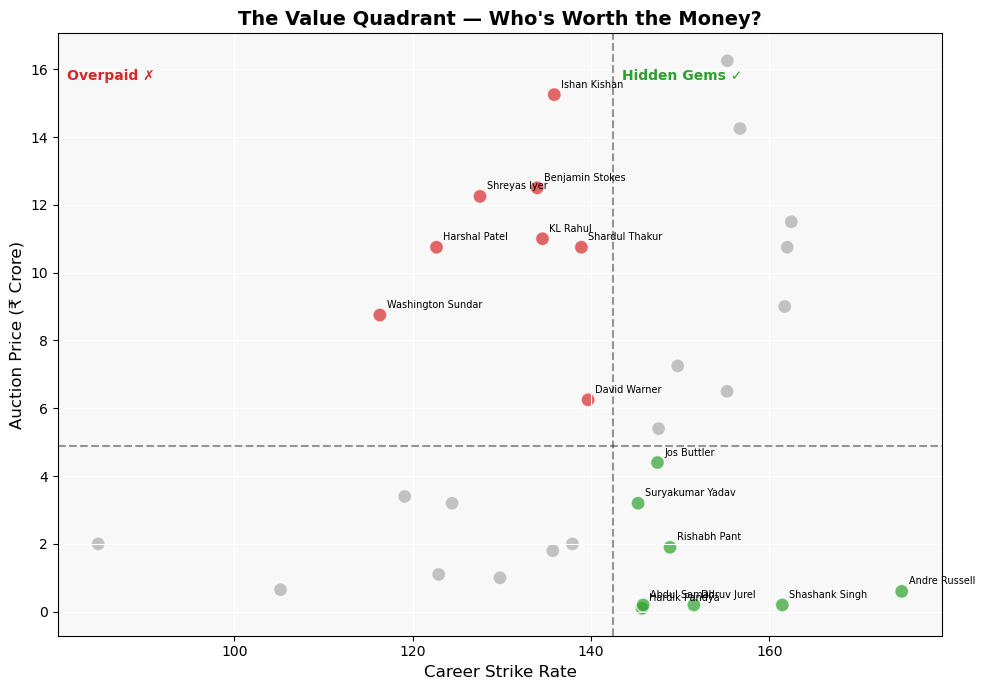

In [12]:
# Cell 8 — Plot 5: Value quadrant
fig, ax = plt.subplots(figsize=(10, 7))
med_price = batters_merged['Crore'].median()
med_sr    = batters_merged['strike_rate'].median()

colors = batters_merged.apply(
    lambda r: '#2ca02c' if r['Crore'] < med_price and r['strike_rate'] > med_sr
    else RED if r['Crore'] > med_price and r['strike_rate'] < med_sr
    else '#aaaaaa', axis=1)

ax.scatter(batters_merged['strike_rate'], batters_merged['Crore'],
           c=colors, alpha=0.7, edgecolors='white', s=100)

ax.axvline(med_sr,    color='black', linestyle='--', alpha=0.4)
ax.axhline(med_price, color='black', linestyle='--', alpha=0.4)

ax.text(med_sr + 1,        ax.get_ylim()[1]*0.92, 'Hidden Gems ✓', color='#2ca02c', fontweight='bold')
ax.text(ax.get_xlim()[0] + 1, ax.get_ylim()[1]*0.92, 'Overpaid ✗', color=RED,       fontweight='bold')

highlighted = batters_merged[colors.isin(['#2ca02c', RED])]
for _, row in highlighted.iterrows():
    ax.annotate(row['Player'], (row['strike_rate'], row['Crore']),
                textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('Career Strike Rate', fontsize=12)
ax.set_ylabel('Auction Price (₹ Crore)', fontsize=12)
ax.set_title("The Value Quadrant — Who's Worth the Money?",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_value_quadrant.png', dpi=150)
plt.show()

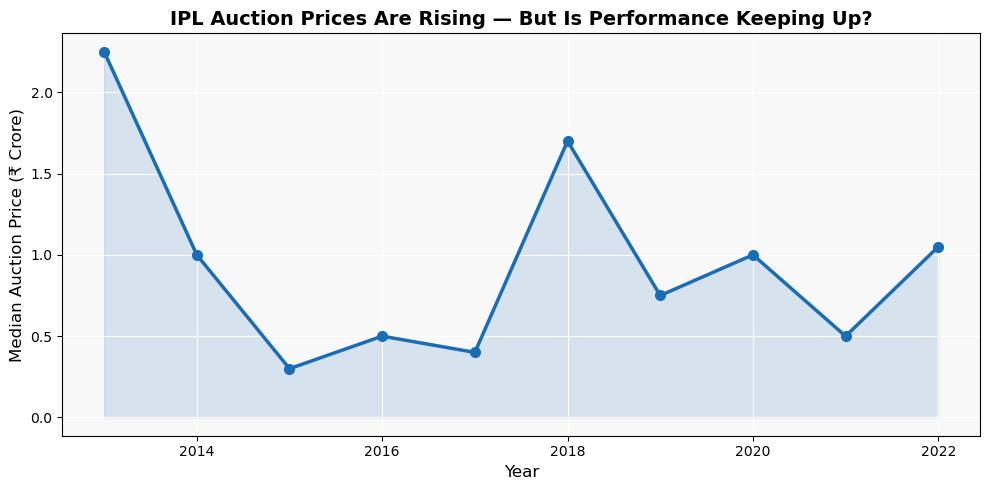

In [13]:
# Cell 9 — Plot 6: Auction price inflation over time
price_time = auction.groupby('Year')['Crore'].median().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(price_time['Year'], price_time['Crore'], color=BLUE,
        linewidth=2.5, marker='o', markersize=7)
ax.fill_between(price_time['Year'], price_time['Crore'], alpha=0.15, color=BLUE)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Auction Price (₹ Crore)', fontsize=12)
ax.set_title('IPL Auction Prices Are Rising — But Is Performance Keeping Up?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_price_inflation.png', dpi=150)
plt.show()

── REGRESSION RESULTS ──
R² score: 0.020
  Total Runs: 0.044
  Strike Rate: 0.712
  Intercept: 6.073


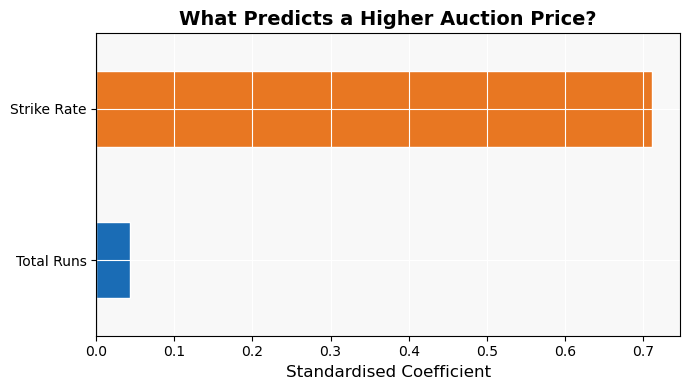

In [14]:
# Cell 10 — Regression: What predicts auction price?
reg_df = batters_merged[['Crore', 'runs', 'strike_rate']].dropna()
X = reg_df[['runs', 'strike_rate']]
y = reg_df['Crore']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

print("── REGRESSION RESULTS ──")
print(f"R² score: {model.score(X_scaled, y):.3f}")
for name, coef in zip(['Total Runs', 'Strike Rate'], model.coef_):
    print(f"  {name}: {coef:.3f}")
print(f"  Intercept: {model.intercept_:.3f}")

# Coefficient plot
fig, ax = plt.subplots(figsize=(7, 4))
coefs = pd.Series(model.coef_, index=['Total Runs', 'Strike Rate'])
coefs.plot(kind='barh', ax=ax, color=[BLUE, ORANGE], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('What Predicts a Higher Auction Price?', fontsize=14, fontweight='bold')
ax.set_xlabel('Standardised Coefficient', fontsize=12)
plt.tight_layout()
plt.savefig('plot7_regression_coefs.png', dpi=150)
plt.show()